# Tutorial 8: Synthetic Routed Network BME

This notebook builds a fully shareable routed network example without relying on SWMM input files.

The workflow mirrors the larger sewer-style network examples while staying self-contained:

1. Generate a branched sewer-like network with dry-weather inflows, a day-of-week pattern, and an hour-of-day pattern.
2. Add one SWMM-style RTK triangular response to represent wet-weather inflow and infiltration.
3. Route the local inflows downstream by link travel time using a nominal velocity of `0.5 ft/s` and minimal attenuation.
4. Treat that routed run as the soft prior signal, then create a perturbed routed run as the latent truth.
5. Sample sparse hard observations from the truth and compare hard-only versus hard-plus-soft network space-time BME.

The routing and inflow-generation logic lives in `pybme.synthetic_network`, so this notebook stays concise and consistent with the runnable example script.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

project_root = Path.cwd().resolve().parent
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from pybme.network import NetworkCovariance, NetworkCovarianceST, adjacency_from_edges
from pybme.network_plots import plot_network_field
from pybme.predict import bme_predict_network_st
from pybme.synthetic_network import (
    build_soft_pdf_inputs,
    prediction_grid,
    simulate_synthetic_routed_network,
    build_synthetic_network_topology,
    hour_of_day_multiplier,
    day_of_week_multiplier,
    make_rain_hyetograph,
    triangular_unit_hydrograph,
    _delay_signal,
    _aggregate_hourly,
    _combine_components,
    _build_local_components,
    _route_local_inflows,
    _add_process_noise,
    SyntheticRoutedNetwork,
    )

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

## 1. Build the Synthetic Routed Dataset

The generator returns both the nominal routed run used as soft data and a perturbed routed run treated as the latent truth. It also prepares sparse hard observations at a subset of sensor nodes.

In [2]:
dataset = simulate_synthetic_routed_network(seed=42)
ck_nodes, tk = prediction_grid(dataset)
cs_nodes, ts, soft_pdfs, soft_std = build_soft_pdf_inputs(dataset)

print(f"Nodes: {len(dataset.node_names)}   Links: {len(dataset.edges)}   Hours: {dataset.truth_matrix.shape[1]}")
print("Sensor nodes:", ", ".join(dataset.sensor_nodes))
print(f"Soft RTK (R, T, K): {dataset.rtk_params_soft}")
print(f"Truth RTK (R, T, K): {dataset.rtk_params_truth}")
print(f"Routing velocity soft/truth: {dataset.velocity_soft_fps:.2f}/{dataset.velocity_truth_fps:.2f} ft/s")
print(f"Hard observations: {len(dataset.hard_values)}")
print(f"Soft PDFs: {len(soft_pdfs)}")

Nodes: 11   Links: 10   Hours: 36
Sensor nodes: JUNC_N, CORE, TRUNK, OUTFALL
Soft RTK (R, T, K): (0.085, 2.0, 3.0)
Truth RTK (R, T, K): (0.095, 2.35, 3.4)
Routing velocity soft/truth: 0.50/0.47 ft/s
Hard observations: 68
Soft PDFs: 328


## 2. Inspect the Forcing and Local Inflow Structure

The first panel shows rainfall, the second shows a representative source node with dry-weather plus RTK response, and the third compares the routed soft run and truth at the outfall.

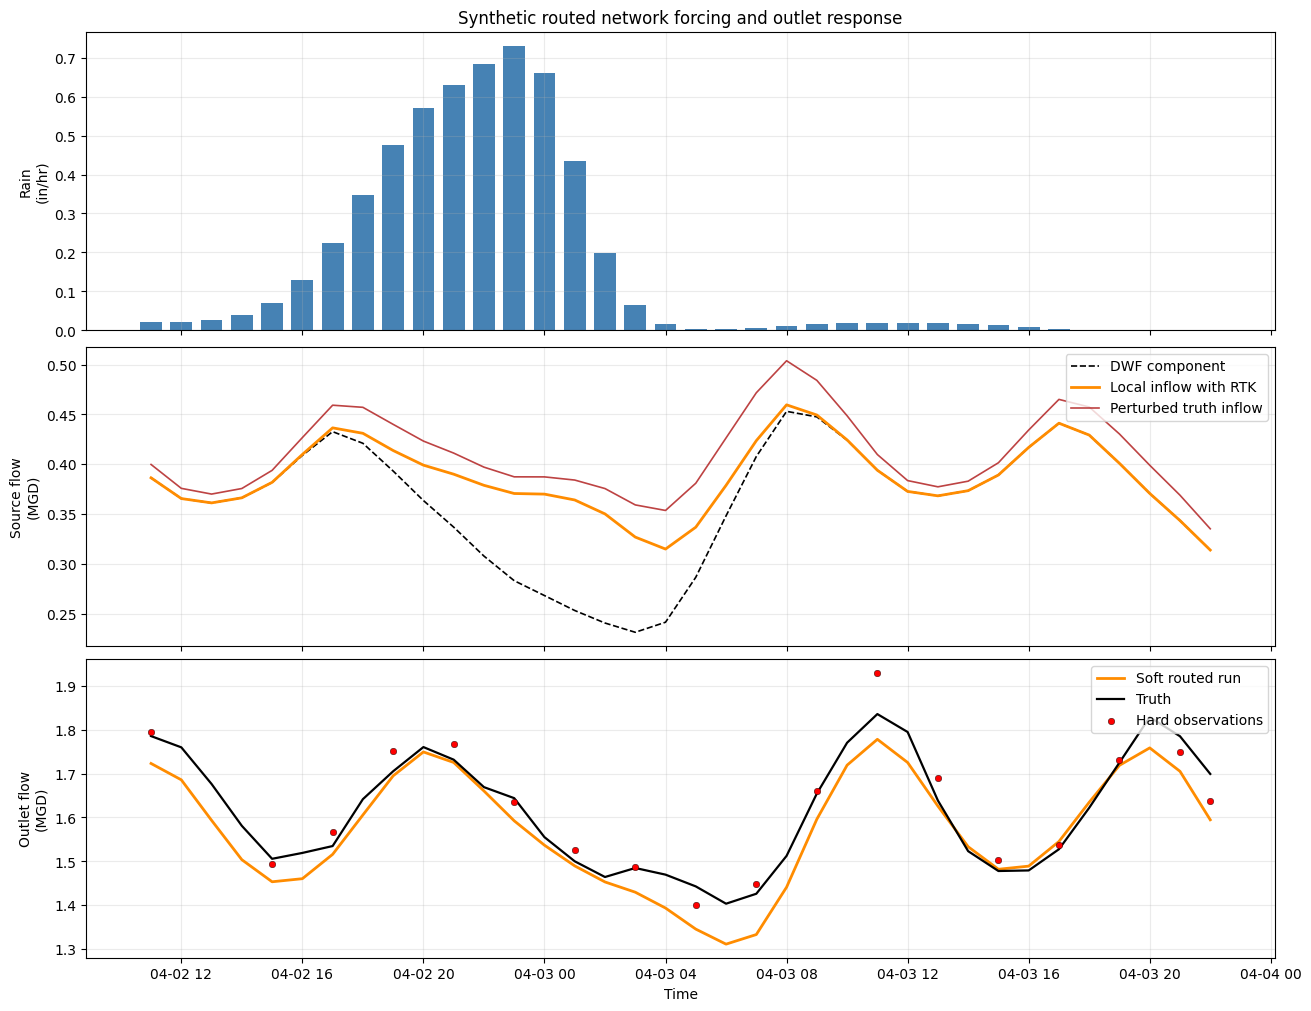

In [3]:
source_name = 'NORTH_A'
outfall_idx = dataset.node_names.index('OUTFALL')
obs_mask = ~np.isnan(dataset.hard_observation_matrix[outfall_idx])

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True, constrained_layout=True)
axes[0].bar(dataset.datetimes, dataset.rain, width=0.03, color='steelblue', edgecolor='none')
axes[0].set_ylabel('Rain\n(in/hr)')
axes[0].set_title('Synthetic routed network forcing and outlet response')

axes[1].plot(dataset.datetimes, dataset.dry_weather_soft[source_name], color='black', linestyle='--', linewidth=1.2, label='DWF component')
axes[1].plot(dataset.datetimes, dataset.local_soft[source_name], color='darkorange', linewidth=2.0, label='Local inflow with RTK')
axes[1].plot(dataset.datetimes, dataset.local_truth[source_name], color='firebrick', linewidth=1.2, alpha=0.85, label='Perturbed truth inflow')
axes[1].set_ylabel('Source flow\n(MGD)')
axes[1].legend(loc='upper right')

axes[2].plot(dataset.datetimes, dataset.soft_matrix[outfall_idx], color='darkorange', linewidth=2.0, label='Soft routed run')
axes[2].plot(dataset.datetimes, dataset.truth_matrix[outfall_idx], color='black', linewidth=1.6, label='Truth')
axes[2].scatter(np.array(dataset.datetimes)[obs_mask], dataset.hard_observation_matrix[outfall_idx][obs_mask], color='red', edgecolor='k', linewidth=0.3, s=22, zorder=4, label='Hard observations')
axes[2].set_ylabel('Outlet flow\n(MGD)')
axes[2].set_xlabel('Time')
axes[2].legend(loc='upper right')
plt.show()

## 3. Run Network Space-Time BME

We use the graph-Laplacian network covariance for the spatial structure and an exponential temporal covariance for the hourly dynamics. Then we compare hard-only and hard-plus-soft prediction across every node and hour in the event window.

In [4]:
n_nodes, n_times = dataset.truth_matrix.shape
W = adjacency_from_edges(n_nodes, dataset.edge_array)
sigma2 = max(float(np.var(dataset.soft_matrix)), 0.02)

net_cov = NetworkCovariance(W, kappa=0.55, sigma2=sigma2, from_adjacency=True)
net_cov_st = NetworkCovarianceST(
    net_cov,
    model_t='exponential',
    params_t=[1.0, 3.0],
    sigma2=sigma2,
)

hard_only = bme_predict_network_st(
    ck_nodes=ck_nodes,
    tk=tk,
    ch_nodes=dataset.hard_nodes,
    th=dataset.hard_times,
    zh=dataset.hard_values,
    net_cov_st=net_cov_st,
    nhmax=28,
    nsmax=0,
    order=0,
    n_grid=101,
    mean_prior=float(np.mean(dataset.hard_values)),
)

hard_soft = bme_predict_network_st(
    ck_nodes=ck_nodes,
    tk=tk,
    ch_nodes=dataset.hard_nodes,
    th=dataset.hard_times,
    zh=dataset.hard_values,
    cs_nodes=cs_nodes,
    ts=ts,
    soft_pdfs=soft_pdfs,
    net_cov_st=net_cov_st,
    nhmax=28,
    nsmax=14,
    order=0,
    n_grid=101,
    mean_prior=float(np.mean(dataset.hard_values)),
)

hard_only_mean = np.array([result.mean for result in hard_only]).reshape(n_nodes, n_times)
hard_only_std = np.array([np.sqrt(result.variance) for result in hard_only]).reshape(n_nodes, n_times)
hard_soft_mean = np.array([result.mean for result in hard_soft]).reshape(n_nodes, n_times)
hard_soft_std = np.array([np.sqrt(result.variance) for result in hard_soft]).reshape(n_nodes, n_times)

    BME ST: 396/396 (100%)    
    BME ST: 396/396 (100%)    


In [5]:
rmse_hard_only = float(np.sqrt(np.mean((hard_only_mean - dataset.truth_matrix) ** 2)))
rmse_hard_soft = float(np.sqrt(np.mean((hard_soft_mean - dataset.truth_matrix) ** 2)))
avg_std_hard_only = float(np.mean(hard_only_std))
avg_std_hard_soft = float(np.mean(hard_soft_std))

print(f'RMSE hard only:   {rmse_hard_only:.4f}')
print(f'RMSE hard + soft: {rmse_hard_soft:.4f}')
print(f'Average posterior std, hard only:   {avg_std_hard_only:.4f}')
print(f'Average posterior std, hard + soft: {avg_std_hard_soft:.4f}')

RMSE hard only:   0.7052
RMSE hard + soft: 0.0443
Average posterior std, hard only:   0.3962
Average posterior std, hard + soft: 0.0664


## 4. Compare the Routed Prior, Truth, and BME Fields

At the outfall peak we can see how the hard-plus-soft solution follows the routed prior while still honoring the sparse observations and the perturbed truth.

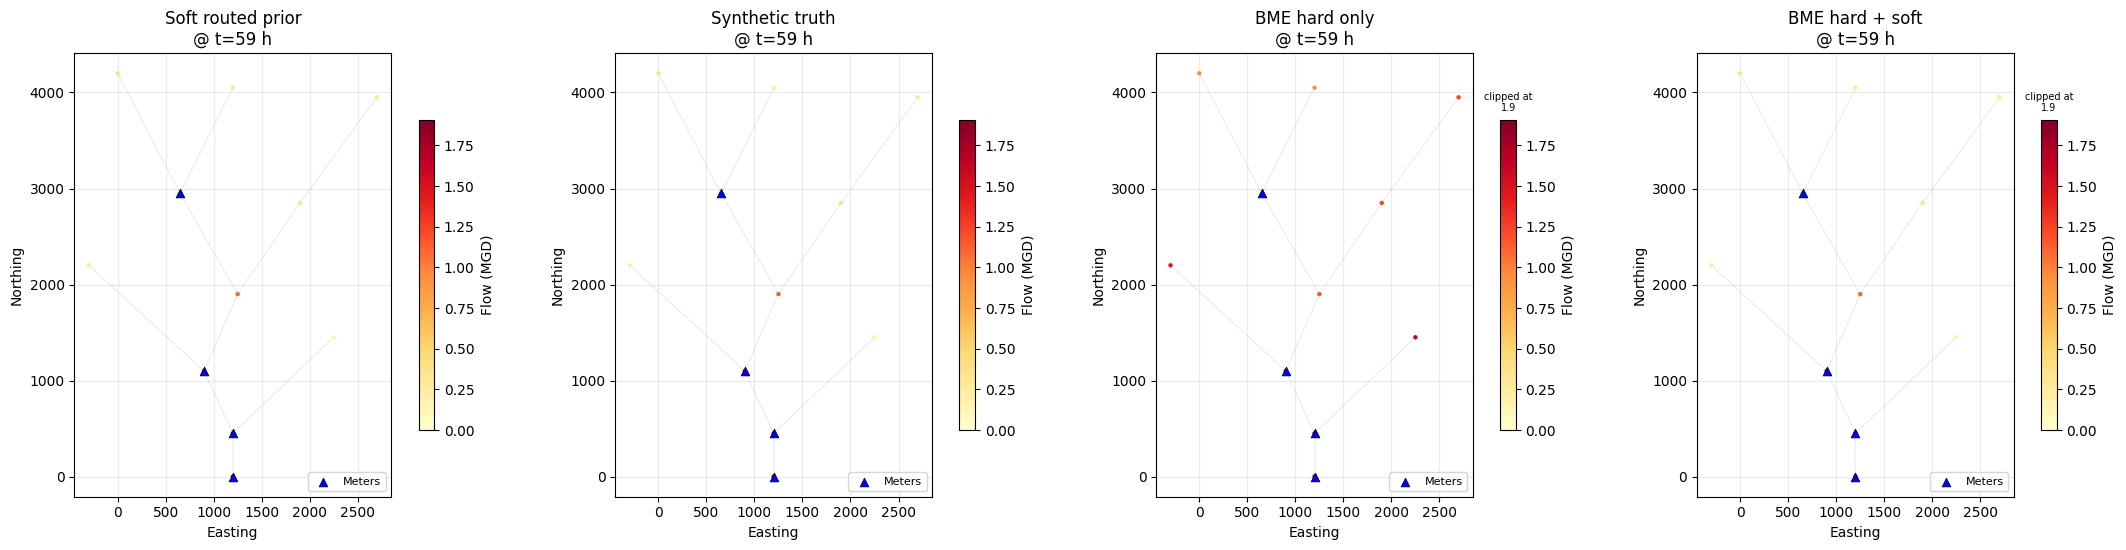

In [6]:
sensor_idx = [dataset.node_names.index(name) for name in dataset.sensor_nodes]
peak_ti = int(np.argmax(dataset.truth_matrix[dataset.node_names.index('OUTFALL')]))
vmax = float(np.percentile(np.concatenate([dataset.soft_matrix[:, peak_ti], dataset.truth_matrix[:, peak_ti], hard_only_mean[:, peak_ti], hard_soft_mean[:, peak_ti]]), 97))

fig, axes = plt.subplots(1, 4, figsize=(22, 5.6))
field_specs = [
    (dataset.soft_matrix[:, peak_ti], 'Soft routed prior'),
    (dataset.truth_matrix[:, peak_ti], 'Synthetic truth'),
    (hard_only_mean[:, peak_ti], 'BME hard only'),
    (hard_soft_mean[:, peak_ti], 'BME hard + soft'),
]
for ax, (values, title) in zip(axes, field_specs):
    plot_network_field(
        dataset.node_names,
        dataset.coords,
        dataset.edges,
        values,
        obs_nodes=sensor_idx,
        title=f'{title}\n@ t={dataset.times_hours[peak_ti]:.0f} h',
        units='Flow (MGD)',
        vmin=0.0,
        vmax=vmax,
        ax=ax,
    )
plt.show()

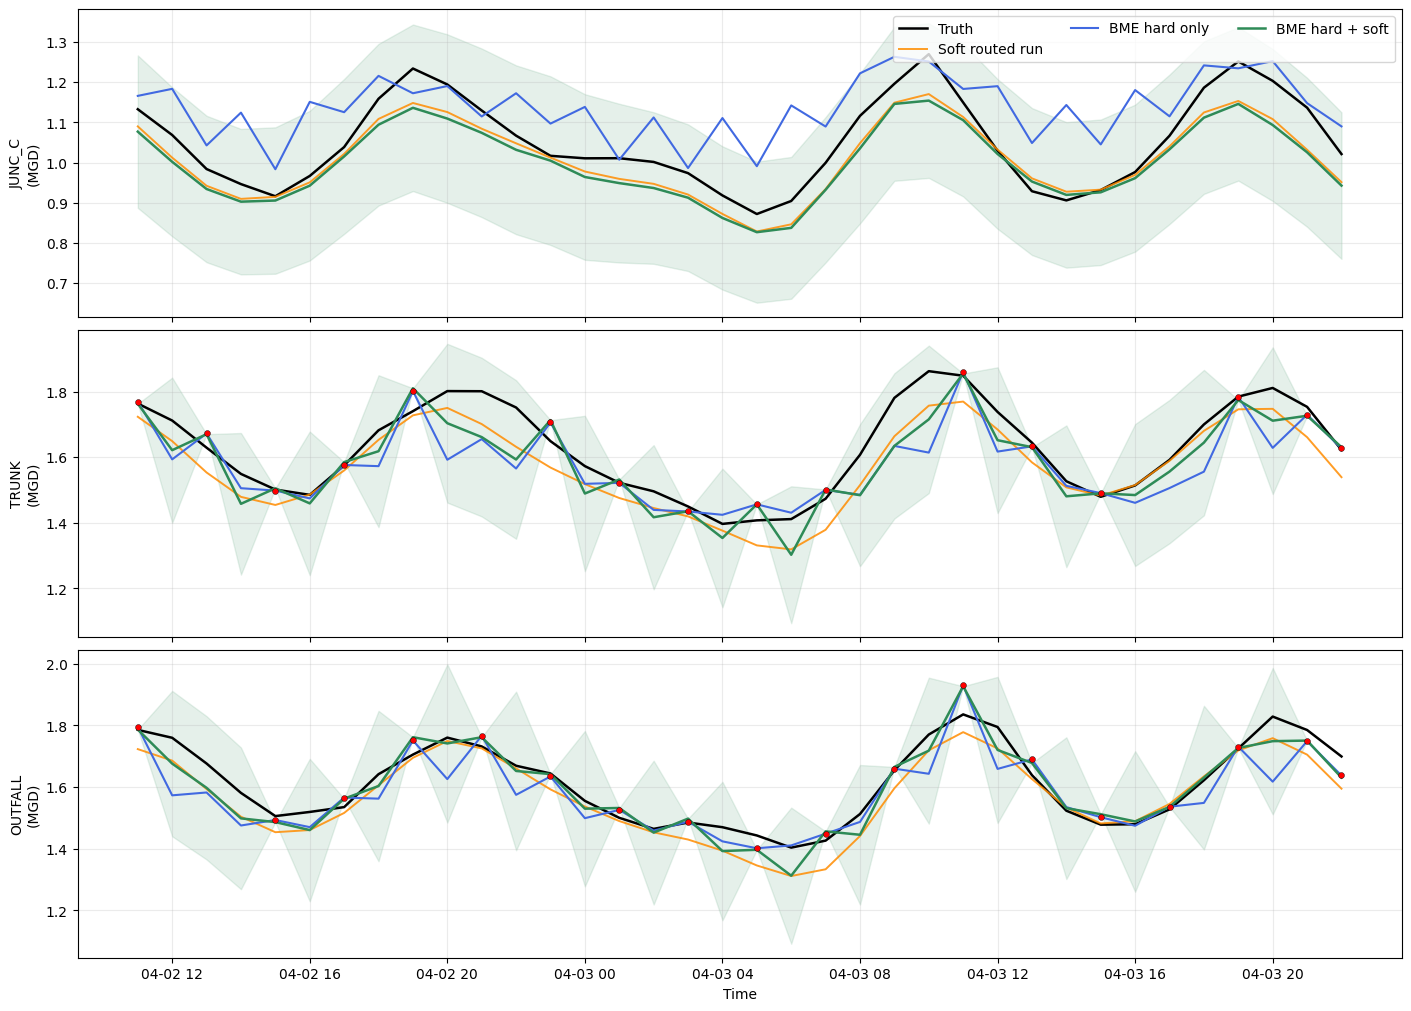

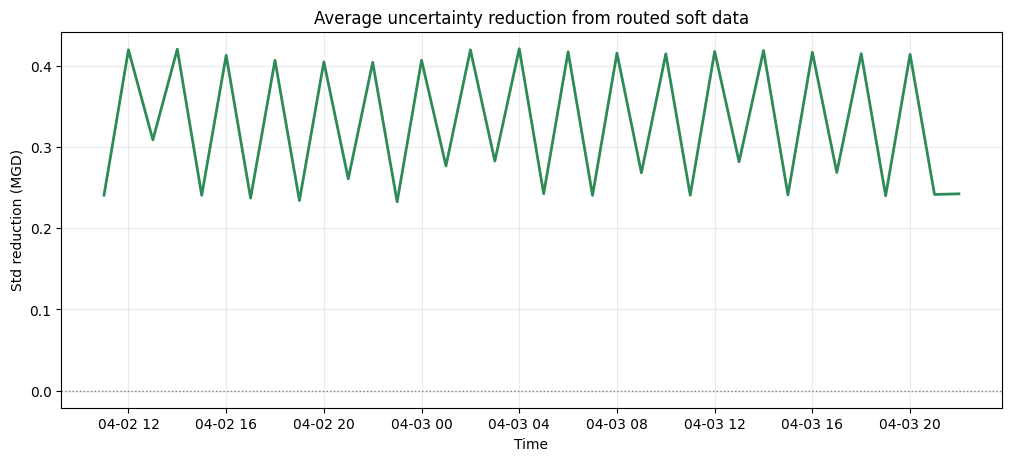

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, constrained_layout=True)
for ax, node_name in zip(axes, ['JUNC_C', 'TRUNK', 'OUTFALL']):
    node_idx = dataset.node_names.index(node_name)
    ax.plot(dataset.datetimes, dataset.truth_matrix[node_idx], color='black', linewidth=1.8, label='Truth')
    ax.plot(dataset.datetimes, dataset.soft_matrix[node_idx], color='darkorange', linewidth=1.4, alpha=0.85, label='Soft routed run')
    ax.plot(dataset.datetimes, hard_only_mean[node_idx], color='royalblue', linewidth=1.5, label='BME hard only')
    ax.plot(dataset.datetimes, hard_soft_mean[node_idx], color='seagreen', linewidth=1.8, label='BME hard + soft')
    obs_mask = ~np.isnan(dataset.hard_observation_matrix[node_idx])
    if obs_mask.any():
        ax.scatter(np.array(dataset.datetimes)[obs_mask], dataset.hard_observation_matrix[node_idx][obs_mask], color='red', edgecolor='k', linewidth=0.3, s=18, zorder=5, label='Hard observations')
    ax.fill_between(
        dataset.datetimes,
        hard_soft_mean[node_idx] - 1.96 * hard_soft_std[node_idx],
        hard_soft_mean[node_idx] + 1.96 * hard_soft_std[node_idx],
        color='seagreen',
        alpha=0.12,
    )
    ax.set_ylabel(f'{node_name}\n(MGD)')
axes[0].legend(loc='upper right', ncol=3)
axes[-1].set_xlabel('Time')
plt.show()

fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
uncertainty_reduction = hard_only_std.mean(axis=0) - hard_soft_std.mean(axis=0)
ax.plot(dataset.datetimes, uncertainty_reduction, color='seagreen', linewidth=2.0)
ax.axhline(0.0, color='gray', linestyle=':', linewidth=1.0)
ax.set_title('Average uncertainty reduction from routed soft data')
ax.set_ylabel('Std reduction (MGD)')
ax.set_xlabel('Time')
plt.show()

## 5. Interpretation

This synthetic example is useful when you want a larger routed network tutorial but do not want to depend on a public SWMM model download.

Key modeling choices:

- The soft data are not a vague prior; they are a structured routed run with explicit travel time and wet-weather response.
- The hard data come from a perturbed truth run, so they disagree with the soft run in realistic ways rather than by pure white noise alone.
- The graph-Laplacian covariance handles correlation across the branched network, while the temporal covariance shares information across nearby hours.
- The hard-plus-soft solution should reduce both error and posterior uncertainty relative to hard-only estimation, especially near the storm response.